Question 11
Create delivery performance analysis showing delivery days distribution, on-time performance, and customer satisfaction correlation with delivery speed across different cities and customer tiers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
years = [2015, 2016, 2017, 2018,2019,2020,2021,2022,2023,2024,2025]
dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    dfs.append(pd.read_csv(path))

df = pd.concat(dfs, ignore_index=True)

Median Delivery Days (On-Time Threshold): 3.0


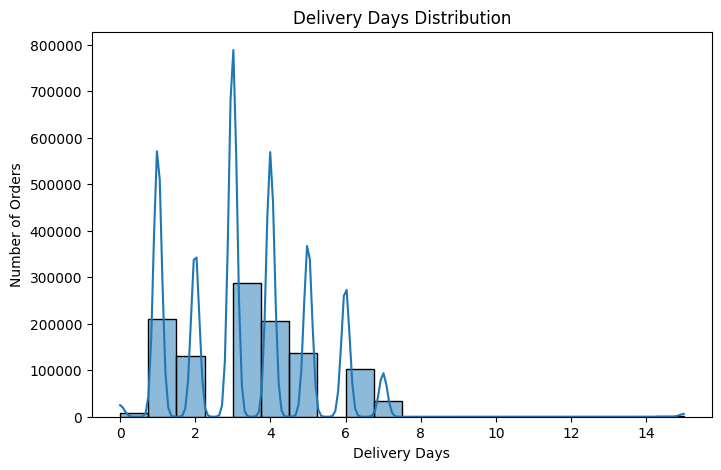

Overall On-Time Delivery Rate: 56.65%


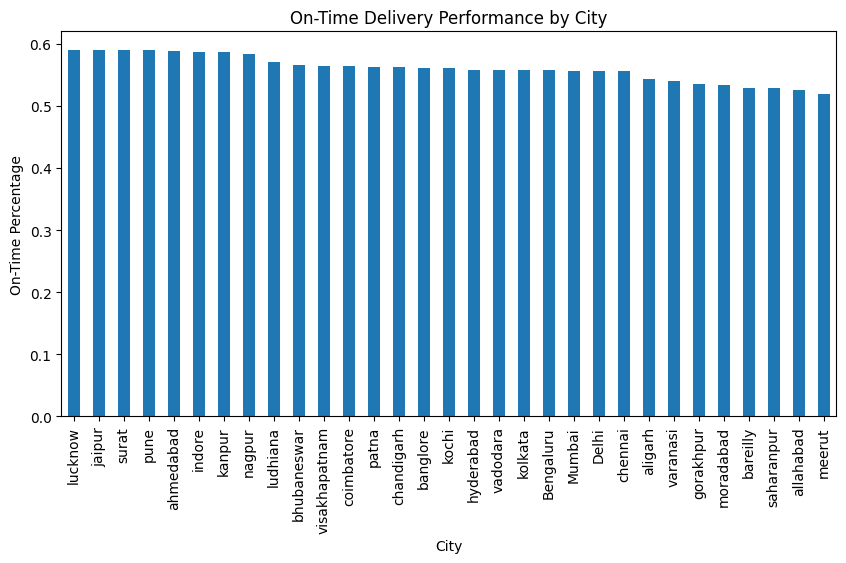

C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


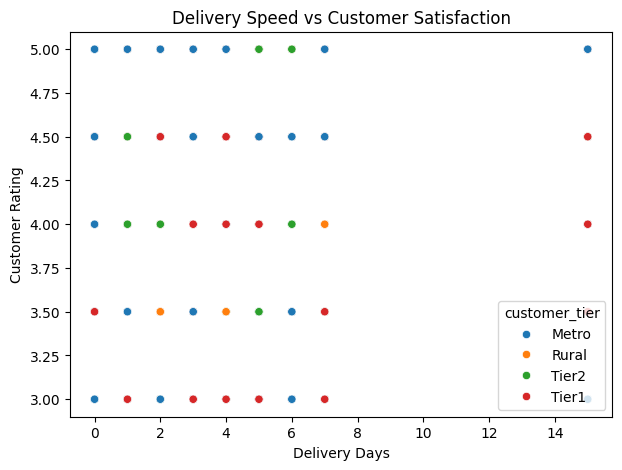


Correlation Matrix:
                 delivery_days  customer_rating
delivery_days         1.000000        -0.046206
customer_rating      -0.046206         1.000000


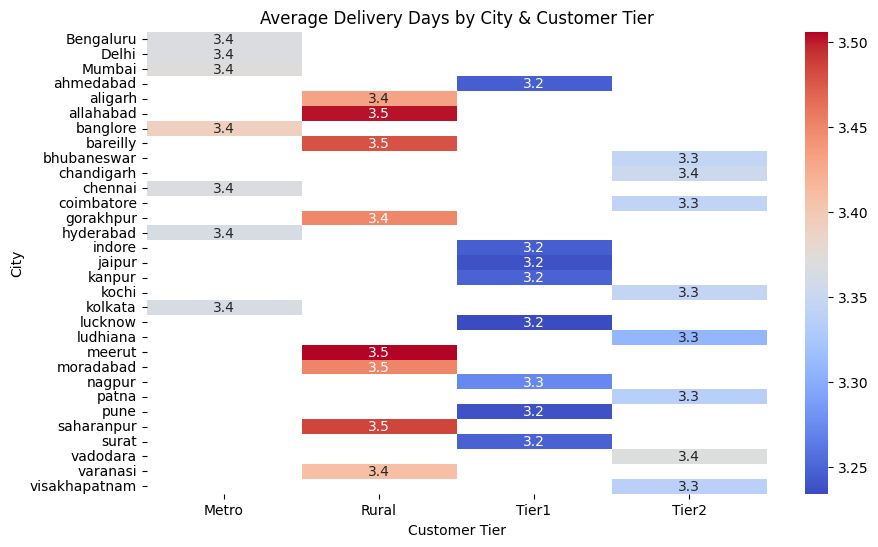

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

years = [2015, 2016, 2017, 2018,2019,2020,2021,2022,2023,2024,2025]
dfs = []

for y in years:
    path = rf"C:\Users\hp\Desktop\Amazon\CSV_Clean_Files\amazon_india_{y}_clean.csv"
    dfs.append(pd.read_csv(path))

df = pd.concat(dfs, ignore_index=True)

median_delivery = df['delivery_days'].median()
df['on_time'] = df['delivery_days'] <= median_delivery

print(f"Median Delivery Days (On-Time Threshold): {median_delivery}")

plt.figure(figsize=(8,5))
sns.histplot(df['delivery_days'], bins=20, kde=True)
plt.title("Delivery Days Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()


overall_ontime = df['on_time'].mean() * 100
print(f"Overall On-Time Delivery Rate: {overall_ontime:.2f}%")

plt.figure(figsize=(10,5))
(df.groupby('customer_city')['on_time']
   .mean()
   .sort_values(ascending=False)
   .plot(kind='bar'))

plt.title("On-Time Delivery Performance by City")
plt.ylabel("On-Time Percentage")
plt.xlabel("City")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='delivery_days',
    y='customer_rating',
    hue='customer_tier'
)
plt.title("Delivery Speed vs Customer Satisfaction")
plt.xlabel("Delivery Days")
plt.ylabel("Customer Rating")
plt.show()

corr = df[['delivery_days', 'customer_rating']].corr()
print("\nCorrelation Matrix:")
print(corr)

pivot = df.pivot_table(
    values='delivery_days',
    index='customer_city',
    columns='customer_tier',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='coolwarm')
plt.title("Average Delivery Days by City & Customer Tier")
plt.xlabel("Customer Tier")
plt.ylabel("City")
plt.show()


Question 12
Analyze return patterns and customer satisfaction using return rates, reasons, and correlation with product ratings, prices, and categories through multiple visualization techniques.

Overall Return Rate: 0.00%


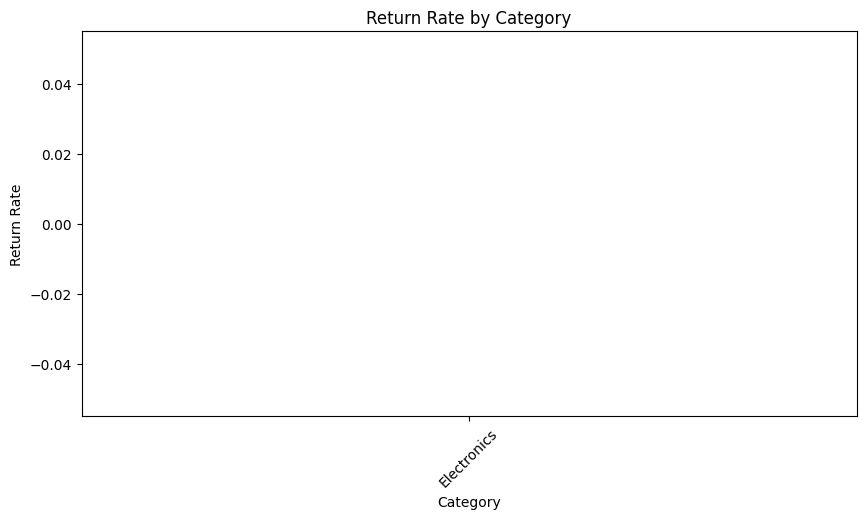

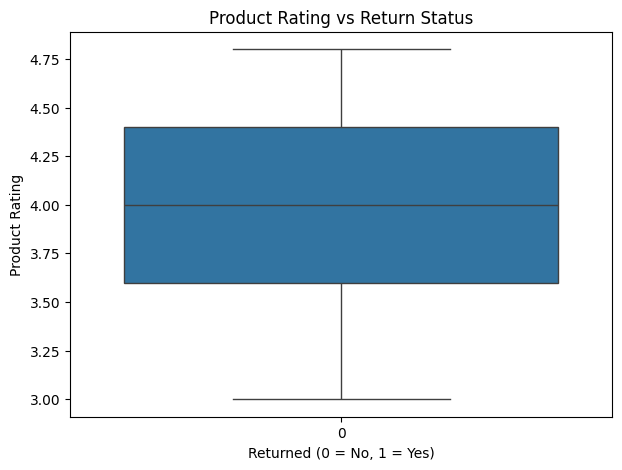

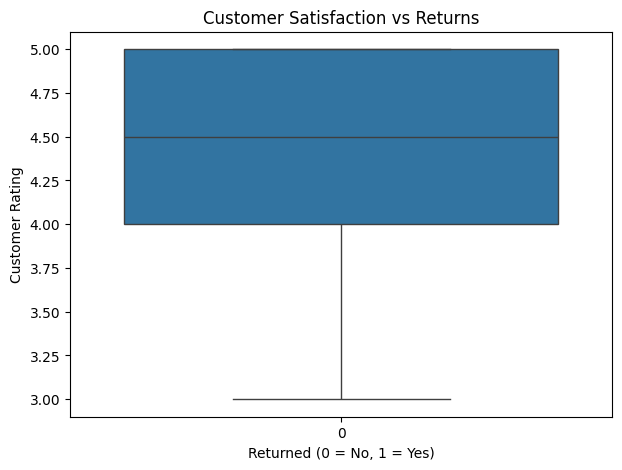

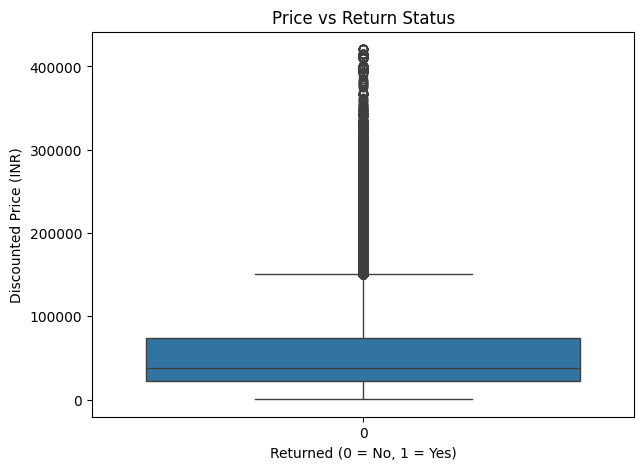


Correlation Matrix:
                      return_flag  discounted_price_inr  product_rating  \
return_flag                   NaN                   NaN             NaN   
discounted_price_inr          NaN              1.000000        0.034027   
product_rating                NaN              0.034027        1.000000   
customer_rating               NaN              0.114985        0.005982   

                      customer_rating  
return_flag                       NaN  
discounted_price_inr         0.114985  
product_rating               0.005982  
customer_rating              1.000000  


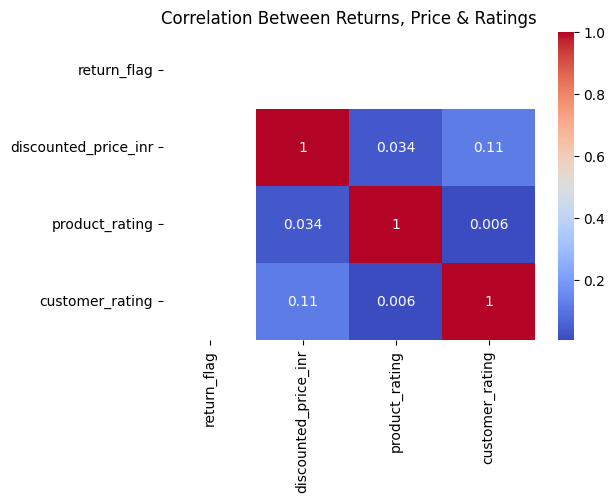

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['return_flag'] = df['return_status'].apply(
    lambda x: 1 if x == 'Returned' else 0
)

overall_return_rate = df['return_flag'].mean() * 100
print(f"Overall Return Rate: {overall_return_rate:.2f}%")

plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='category',
    y='return_flag',
    estimator='mean',
    errorbar=None
)
plt.title("Return Rate by Category")
plt.ylabel("Return Rate")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x='return_flag',
    y='product_rating'
)
plt.title("Product Rating vs Return Status")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Product Rating")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x='return_flag',
    y='customer_rating'
)
plt.title("Customer Satisfaction vs Returns")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Customer Rating")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x='return_flag',
    y='discounted_price_inr'
)
plt.title("Price vs Return Status")
plt.xlabel("Returned (0 = No, 1 = Yes)")
plt.ylabel("Discounted Price (INR)")
plt.show()

corr = df[
    ['return_flag', 'discounted_price_inr', 'product_rating', 'customer_rating']
].corr()

print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Returns, Price & Ratings")
plt.show()


Question 13
Study brand performance and market share evolution. Create brand comparison charts, market share trends, and competitive positioning analysis across different categories.

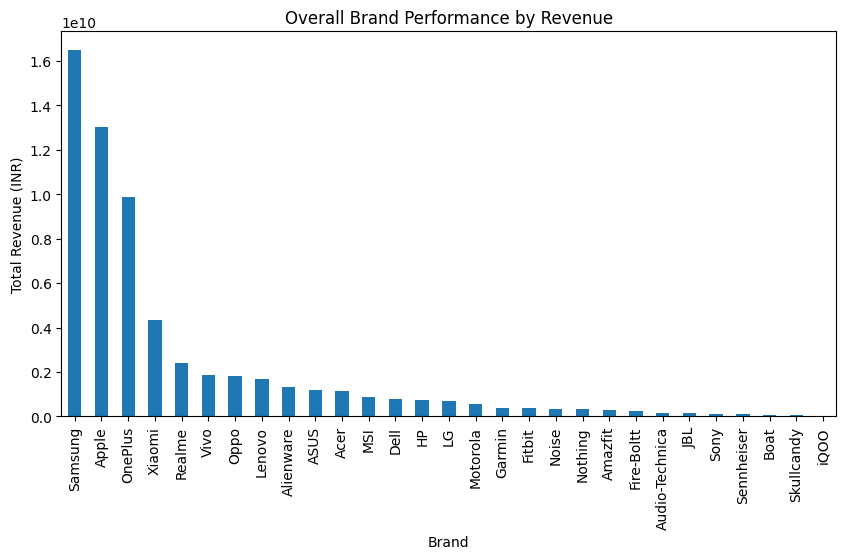

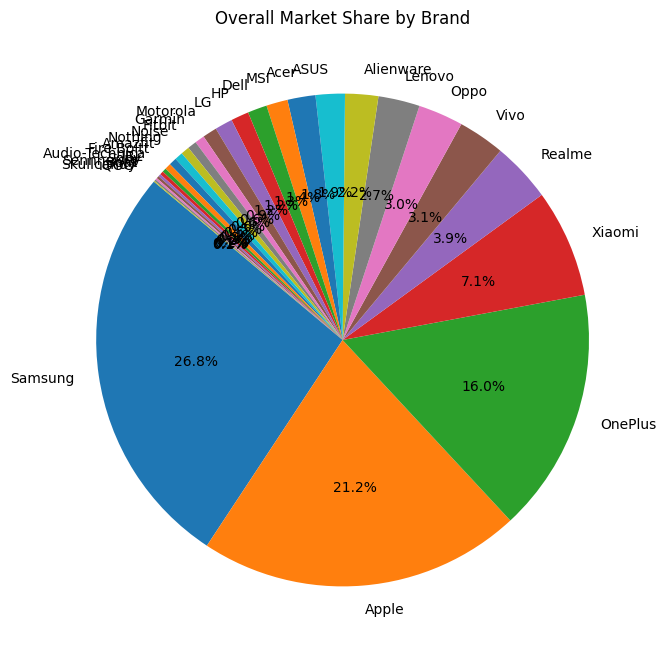

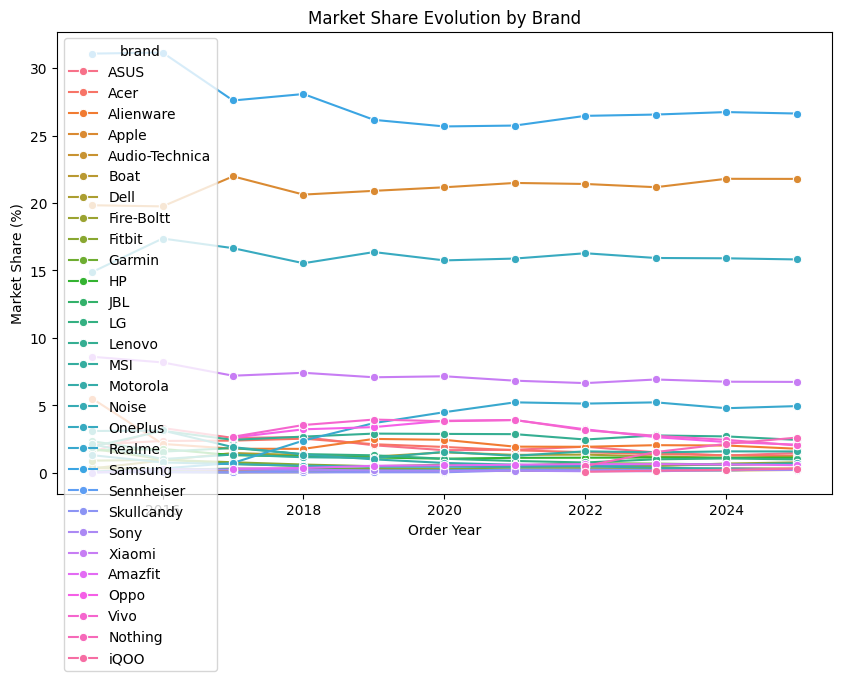

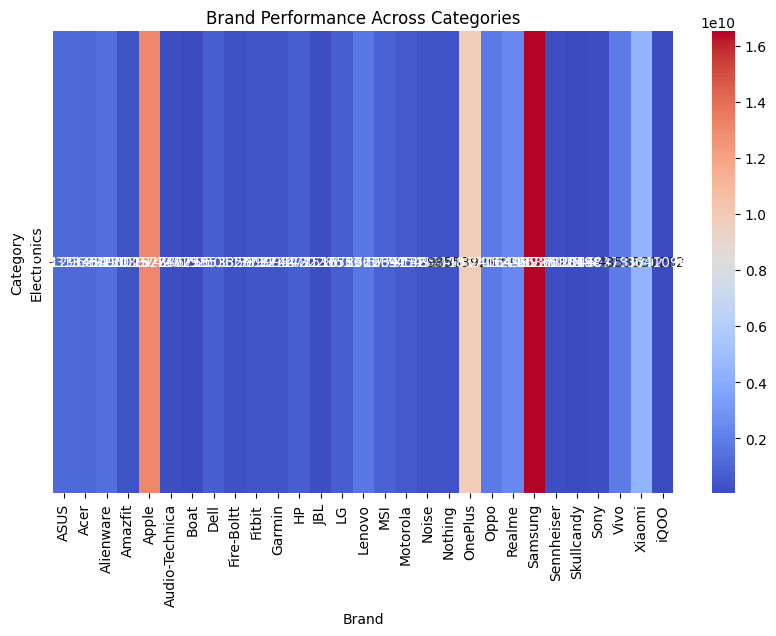

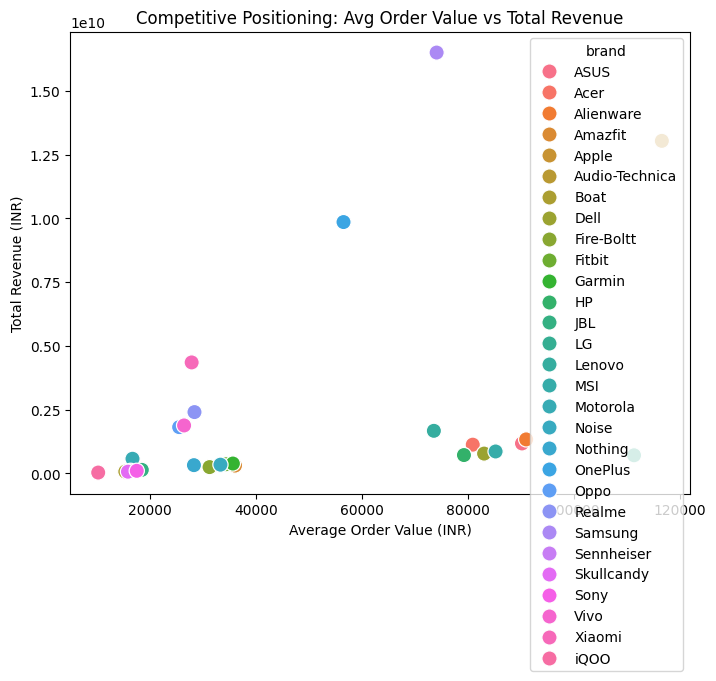

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['order_year'] = df['order_year'].astype(int)

brand_sales = (
    df.groupby('brand')['discounted_price_inr']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
brand_sales.plot(kind='bar')
plt.title("Overall Brand Performance by Revenue")
plt.ylabel("Total Revenue (INR)")
plt.xlabel("Brand")
plt.show()

market_share = brand_sales / brand_sales.sum() * 100

plt.figure(figsize=(8,8))
market_share.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Overall Market Share by Brand")
plt.ylabel("")
plt.show()

year_brand_sales = (
    df.groupby(['order_year', 'brand'])['discounted_price_inr']
      .sum()
      .reset_index()
)

total_year_sales = (
    df.groupby('order_year')['discounted_price_inr']
      .sum()
      .reset_index()
)

market_trend = pd.merge(
    year_brand_sales,
    total_year_sales,
    on='order_year',
    suffixes=('', '_total')
)

market_trend['market_share'] = (
    market_trend['discounted_price_inr'] /
    market_trend['discounted_price_inr_total'] * 100
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=market_trend,
    x='order_year',
    y='market_share',
    hue='brand',
    marker='o'
)
plt.title("Market Share Evolution by Brand")
plt.ylabel("Market Share (%)")
plt.xlabel("Order Year")
plt.show()

category_brand = df.pivot_table(
    values='discounted_price_inr',
    index='category',
    columns='brand',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(category_brand, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("Brand Performance Across Categories")
plt.xlabel("Brand")
plt.ylabel("Category")
plt.show()


brand_position = (
    df.groupby('brand')
      .agg(
          total_revenue=('discounted_price_inr', 'sum'),
          avg_order_value=('discounted_price_inr', 'mean')
      )
      .reset_index()
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=brand_position,
    x='avg_order_value',
    y='total_revenue',
    hue='brand',
    s=120
)
plt.title("Competitive Positioning: Avg Order Value vs Total Revenue")
plt.xlabel("Average Order Value (INR)")
plt.ylabel("Total Revenue (INR)")
plt.show()


Question 14
Build customer lifetime value (CLV) analysis using cohort analysis, retention curves, and CLV distribution across different customer segments and acquisition years.

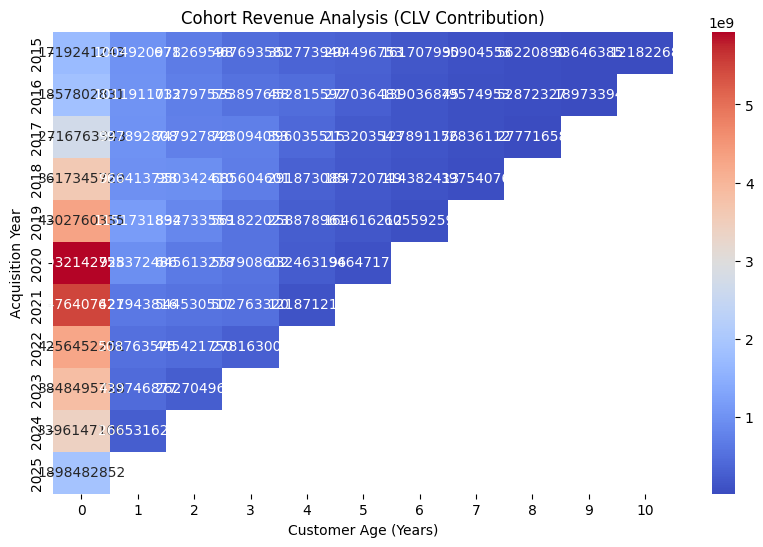

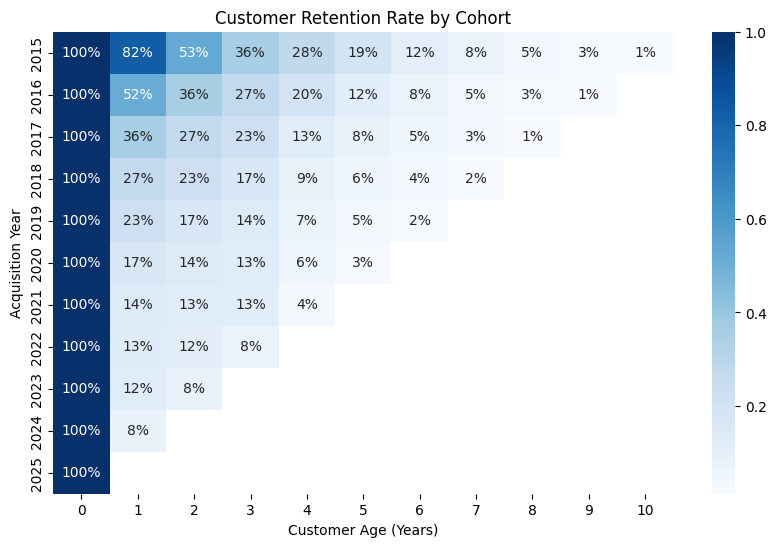

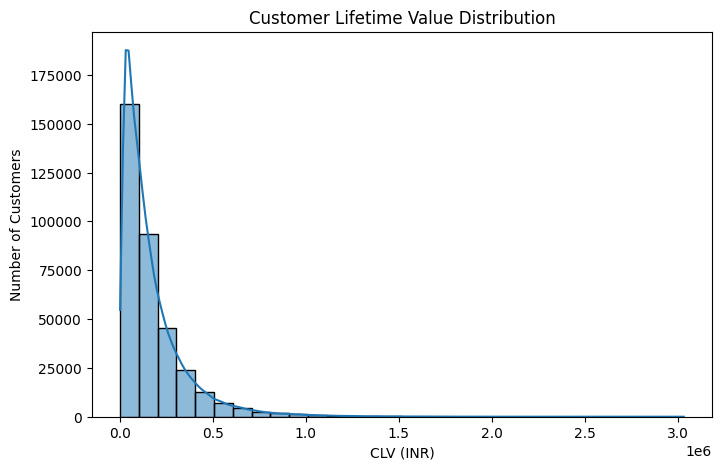

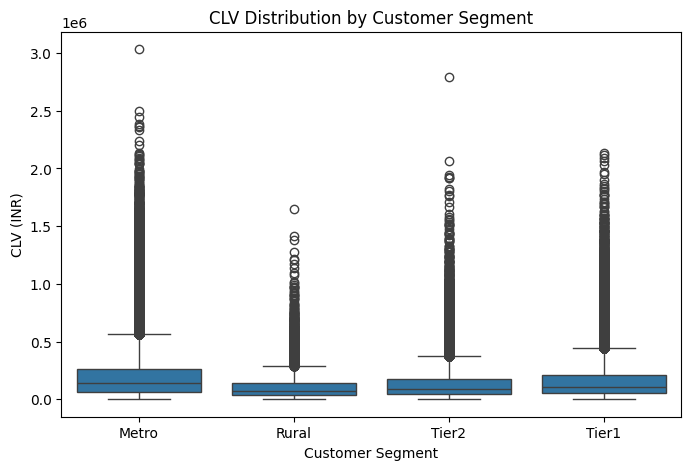

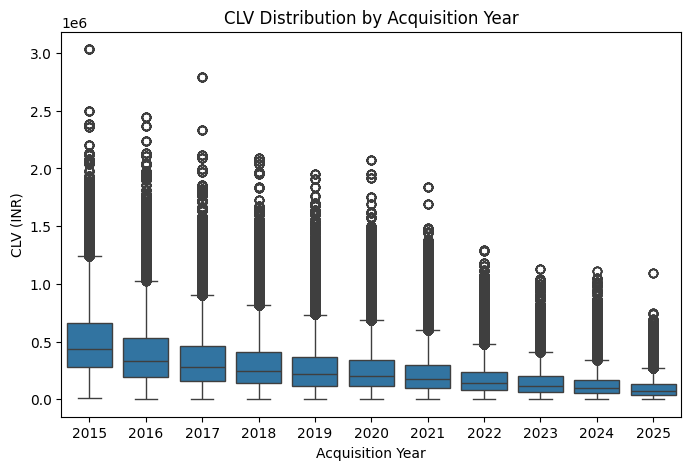

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['order_year'] = df['order_year'].astype(int)

df['acquisition_year'] = df.groupby('customer_id')['order_year'].transform('min')

df['customer_age'] = df['order_year'] - df['acquisition_year']

cohort_revenue = df.pivot_table(
    values='discounted_price_inr',
    index='acquisition_year',
    columns='customer_age',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(cohort_revenue, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("Cohort Revenue Analysis (CLV Contribution)")
plt.xlabel("Customer Age (Years)")
plt.ylabel("Acquisition Year")
plt.show()

cohort_counts = df.pivot_table(
    values='customer_id',
    index='acquisition_year',
    columns='customer_age',
    aggfunc='nunique'
)

retention_rate = cohort_counts.divide(cohort_counts.iloc[:, 0], axis=0)

plt.figure(figsize=(10,6))
sns.heatmap(retention_rate, annot=True, fmt=".0%", cmap='Blues')
plt.title("Customer Retention Rate by Cohort")
plt.xlabel("Customer Age (Years)")
plt.ylabel("Acquisition Year")
plt.show()

clv = (
    df.groupby('customer_id')['discounted_price_inr']
      .sum()
      .reset_index(name='CLV')
)

df_clv = df[['customer_id', 'customer_tier']].drop_duplicates().merge(
    clv, on='customer_id'
)
plt.figure(figsize=(8,5))
sns.histplot(df_clv['CLV'], bins=30, kde=True)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV (INR)")
plt.ylabel("Number of Customers")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='customer_tier',
    y='CLV',
    data=df_clv
)
plt.title("CLV Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("CLV (INR)")
plt.show()

clv_year = df.merge(clv, on='customer_id')

plt.figure(figsize=(8,5))
sns.boxplot(
    x='acquisition_year',
    y='CLV',
    data=clv_year
)
plt.title("CLV Distribution by Acquisition Year")
plt.xlabel("Acquisition Year")
plt.ylabel("CLV (INR)")
plt.show()


Question 15
Analyze discount and promotional effectiveness. Create discount impact analysis showing correlation between discount percentages, sales volumes, and revenue across categories and time periods.


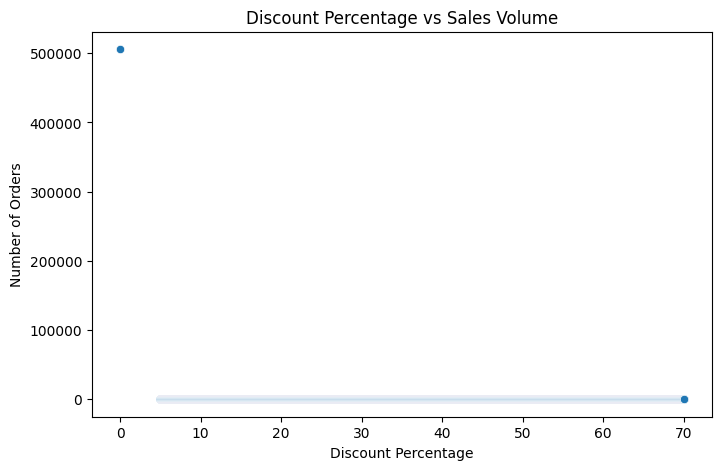

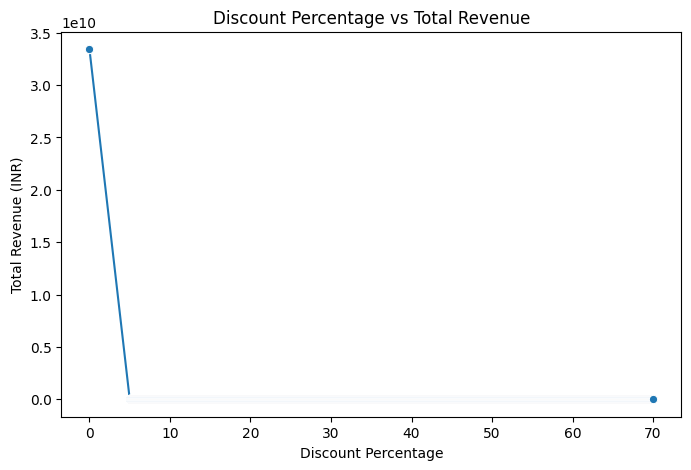

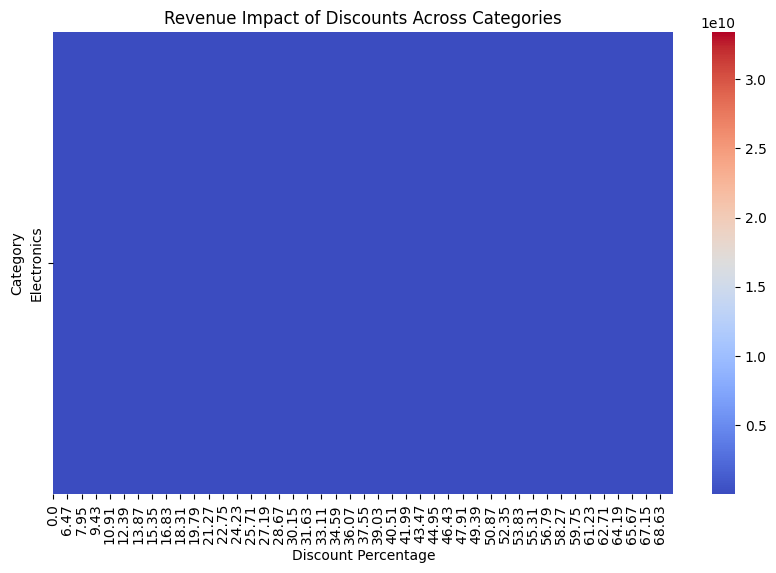

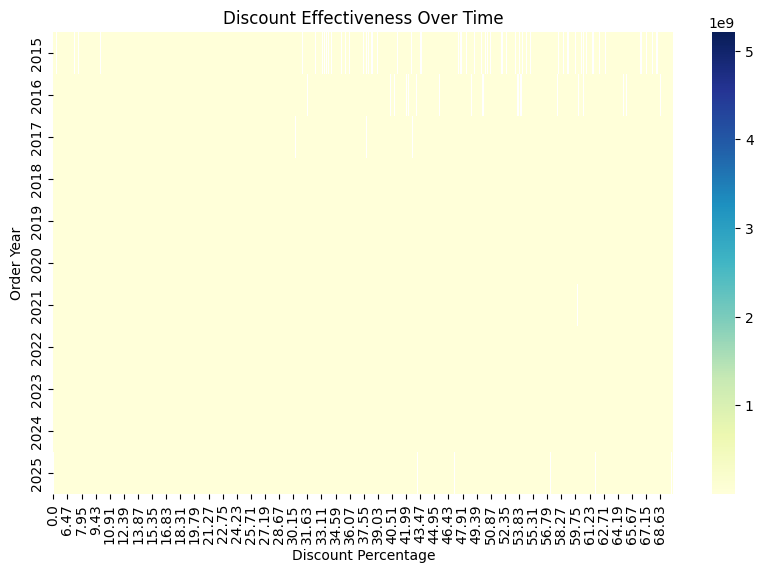


Correlation Matrix:
                      discount_percent  discounted_price_inr
discount_percent              1.000000             -0.296637
discounted_price_inr         -0.296637              1.000000


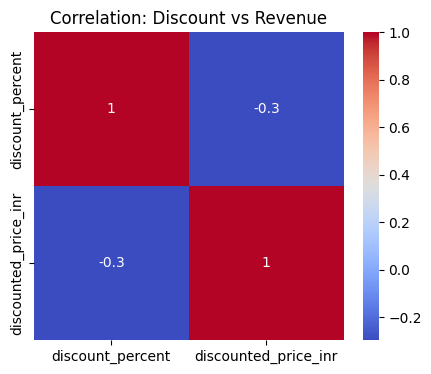

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['order_year'] = df['order_year'].astype(int)

discount_volume = (
    df.groupby('discount_percent')
      .size()
      .reset_index(name='order_count')
)

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=discount_volume,
    x='discount_percent',
    y='order_count'
)
plt.title("Discount Percentage vs Sales Volume")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Orders")
plt.show()

discount_revenue = (
    df.groupby('discount_percent')['discounted_price_inr']
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=discount_revenue,
    x='discount_percent',
    y='discounted_price_inr',
    marker='o'
)
plt.title("Discount Percentage vs Total Revenue")
plt.xlabel("Discount Percentage")
plt.ylabel("Total Revenue (INR)")
plt.show()

category_discount = df.pivot_table(
    values='discounted_price_inr',
    index='category',
    columns='discount_percent',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(category_discount, cmap='coolwarm')
plt.title("Revenue Impact of Discounts Across Categories")
plt.xlabel("Discount Percentage")
plt.ylabel("Category")
plt.show()

time_discount = df.pivot_table(
    values='discounted_price_inr',
    index='order_year',
    columns='discount_percent',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(time_discount, cmap='YlGnBu')
plt.title("Discount Effectiveness Over Time")
plt.xlabel("Discount Percentage")
plt.ylabel("Order Year")
plt.show()

corr = df[['discount_percent', 'discounted_price_inr']].corr()
print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Discount vs Revenue")
plt.show()


Question 16
Study product rating patterns and their impact on sales. Analyze rating distributions, correlation with sales performance, and identify patterns across categories and price ranges.

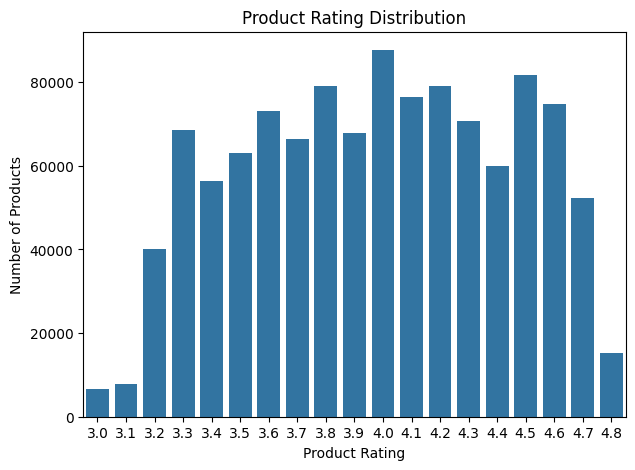

C:\Users\hp\AppData\Local\Temp\ipykernel_11348\3253968751.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rating_bucket')['discounted_price_inr']


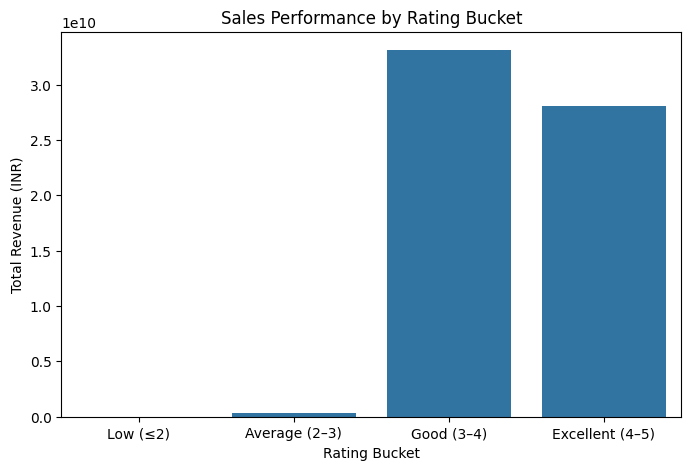


Correlation Matrix:
                      product_rating  discounted_price_inr
product_rating              1.000000              0.034027
discounted_price_inr        0.034027              1.000000


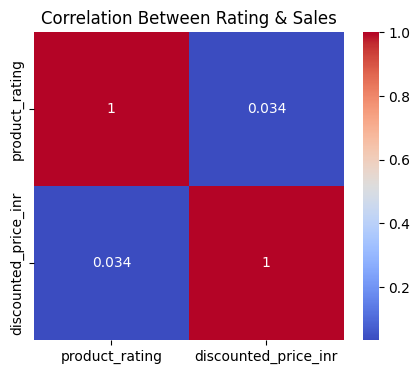

C:\Users\hp\AppData\Local\Temp\ipykernel_11348\3253968751.py:52: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  category_rating = df.pivot_table(


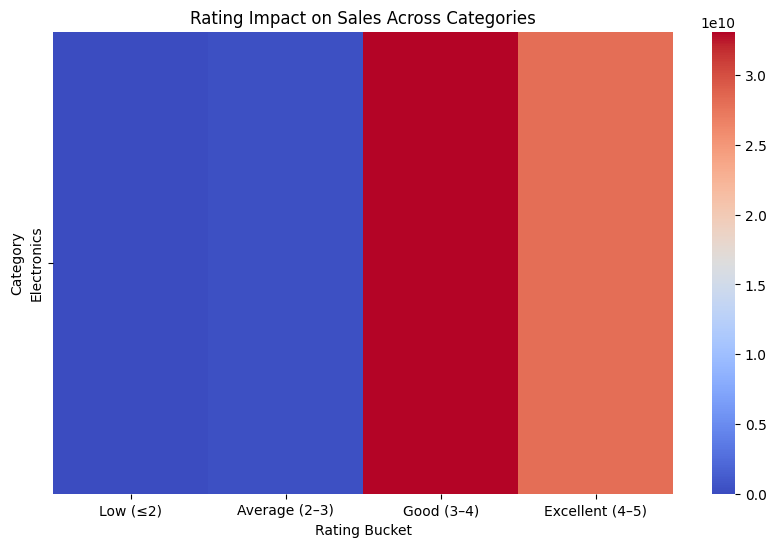

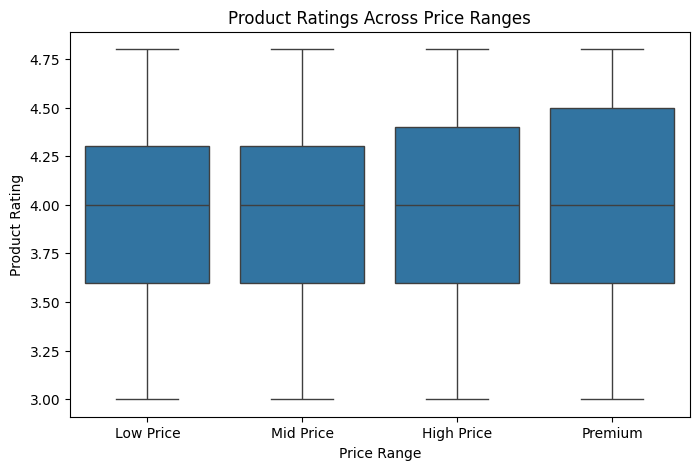

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['order_year'] = df['order_year'].astype(int)

df['rating_bucket'] = pd.cut(
    df['product_rating'],
    bins=[0, 2, 3, 4, 5],
    labels=['Low (≤2)', 'Average (2–3)', 'Good (3–4)', 'Excellent (4–5)']
)

df['price_range'] = pd.qcut(
    df['discounted_price_inr'],
    q=4,
    labels=['Low Price', 'Mid Price', 'High Price', 'Premium']
)

plt.figure(figsize=(7,5))
sns.countplot(x='product_rating', data=df)
plt.title("Product Rating Distribution")
plt.xlabel("Product Rating")
plt.ylabel("Number of Products")
plt.show()

rating_sales = (
    df.groupby('rating_bucket')['discounted_price_inr']
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=rating_sales,
    x='rating_bucket',
    y='discounted_price_inr'
)
plt.title("Sales Performance by Rating Bucket")
plt.xlabel("Rating Bucket")
plt.ylabel("Total Revenue (INR)")
plt.show()

corr = df[['product_rating', 'discounted_price_inr']].corr()
print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Rating & Sales")
plt.show()

category_rating = df.pivot_table(
    values='discounted_price_inr',
    index='category',
    columns='rating_bucket',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(category_rating, cmap='coolwarm')
plt.title("Rating Impact on Sales Across Categories")
plt.xlabel("Rating Bucket")
plt.ylabel("Category")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='price_range',
    y='product_rating',
    data=df
)
plt.title("Product Ratings Across Price Ranges")
plt.xlabel("Price Range")
plt.ylabel("Product Rating")
plt.show()


Question 17
Create customer journey analysis showing purchase frequency patterns, category transitions, and customer evolution from first purchase to loyal customers using flow diagrams and transition matrices.


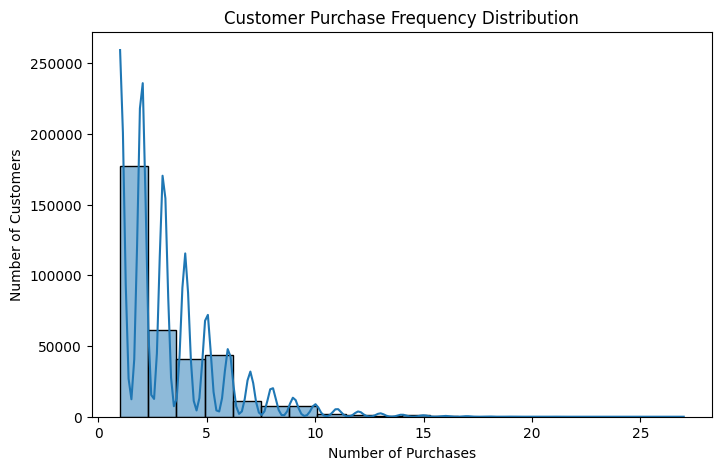

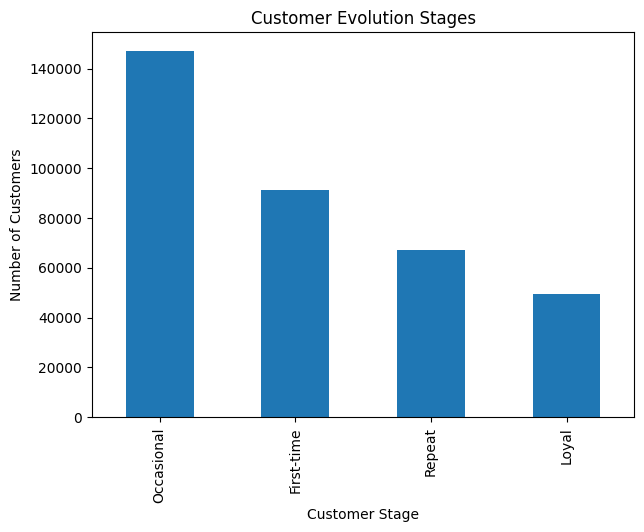

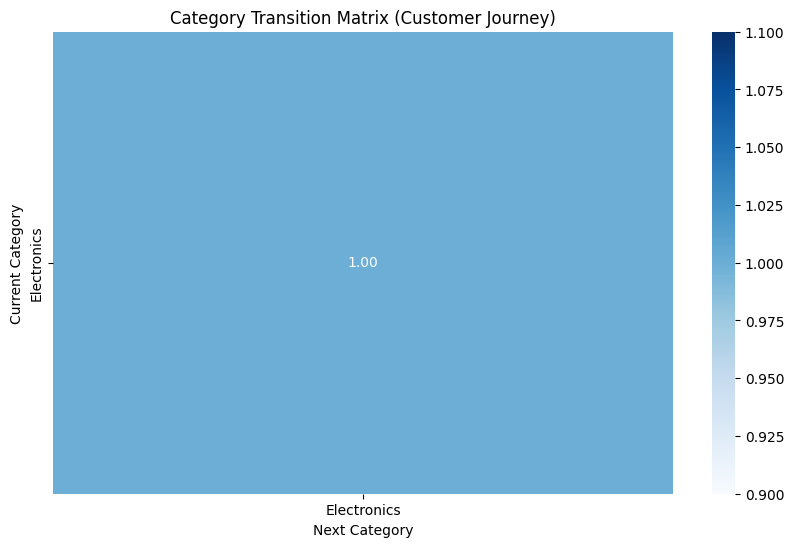

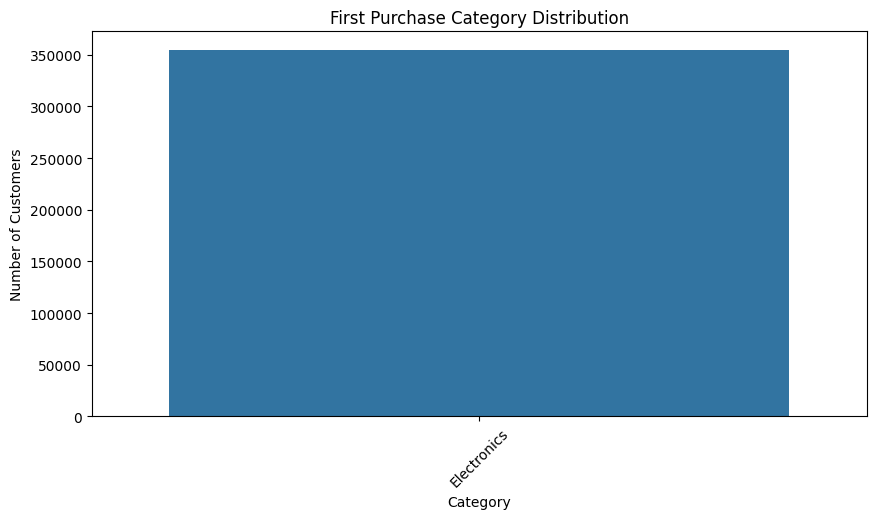

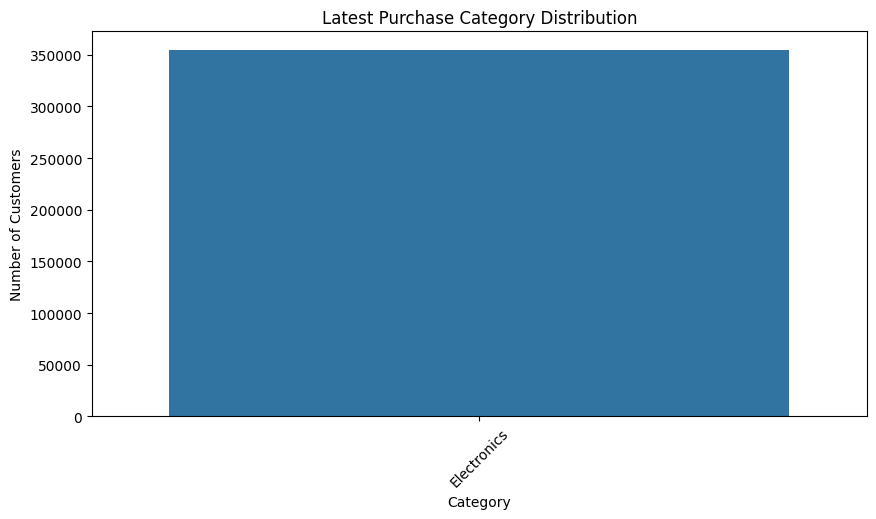

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['order_year'] = df['order_year'].astype(int)

df = df.sort_values(['customer_id', 'order_year'])

purchase_freq = (
    df.groupby('customer_id')
      .size()
      .reset_index(name='purchase_count')
)

plt.figure(figsize=(8,5))
sns.histplot(purchase_freq['purchase_count'], bins=20, kde=True)
plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

purchase_freq['customer_stage'] = pd.cut(
    purchase_freq['purchase_count'],
    bins=[0, 1, 3, 5, purchase_freq['purchase_count'].max()],
    labels=['First-time', 'Occasional', 'Repeat', 'Loyal']
)

plt.figure(figsize=(7,5))
purchase_freq['customer_stage'].value_counts().plot(kind='bar')
plt.title("Customer Evolution Stages")
plt.xlabel("Customer Stage")
plt.ylabel("Number of Customers")
plt.show()

df['next_category'] = df.groupby('customer_id')['category'].shift(-1)

transitions = df.dropna(subset=['next_category'])

transition_matrix = pd.crosstab(
    transitions['category'],
    transitions['next_category'],
    normalize='index'
)

plt.figure(figsize=(10,6))
sns.heatmap(transition_matrix, annot=True, fmt=".2f", cmap='Blues')
plt.title("Category Transition Matrix (Customer Journey)")
plt.xlabel("Next Category")
plt.ylabel("Current Category")
plt.show()

first_purchase = df.groupby('customer_id').first().reset_index()
repeat_purchase = df.groupby('customer_id').last().reset_index()

plt.figure(figsize=(10,5))
sns.countplot(
    x='category',
    data=first_purchase,
    order=first_purchase['category'].value_counts().index
)
plt.title("First Purchase Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(
    x='category',
    data=repeat_purchase,
    order=repeat_purchase['category'].value_counts().index
)
plt.title("Latest Purchase Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()


Question 18
Analyze inventory and product lifecycle patterns. Study product launch success, decline phases, and category evolution over the decade with detailed trend analysis.


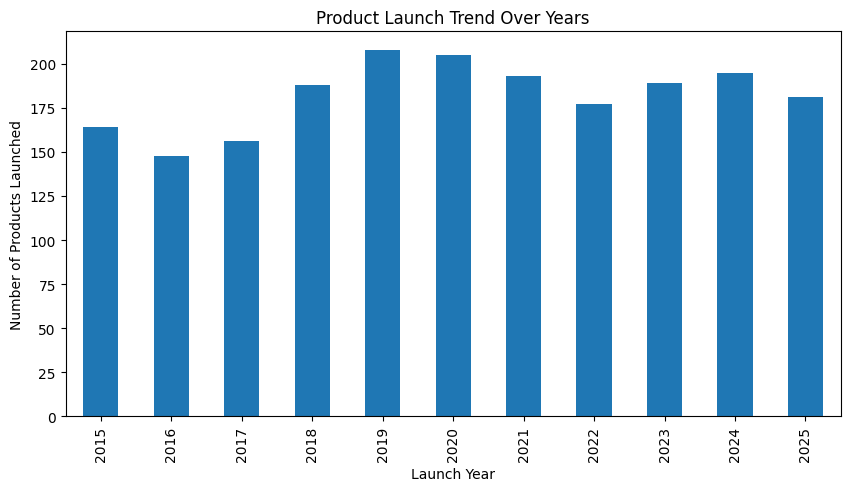

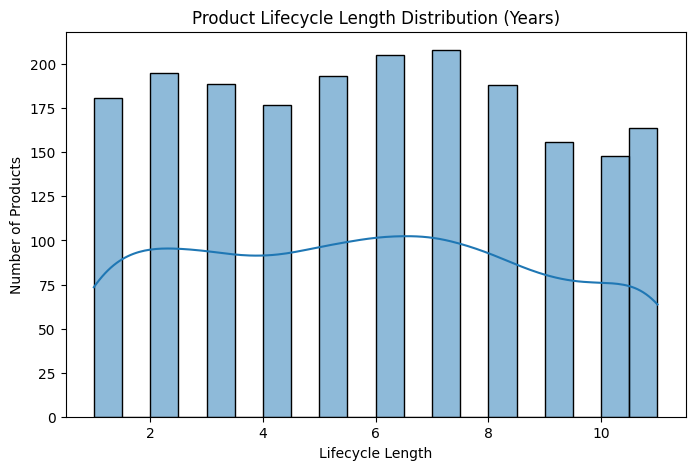

Number of products showing decline phase: 1820


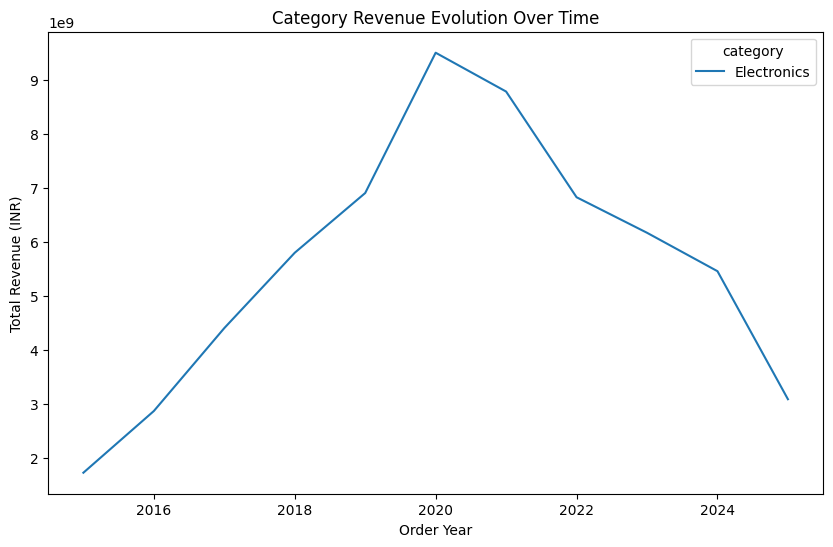

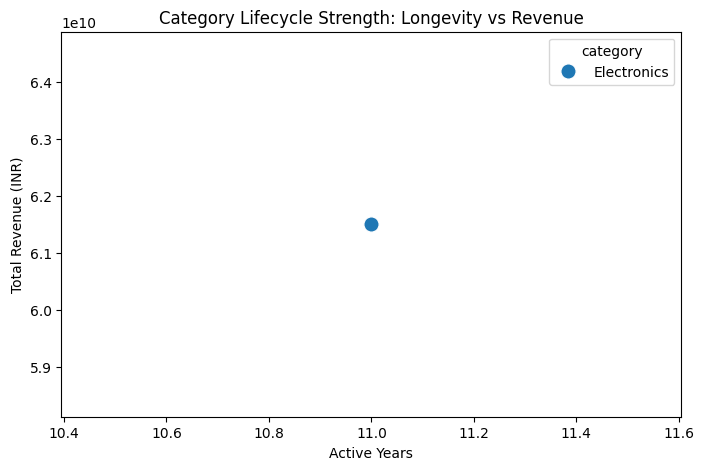

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['order_year'] = df['order_year'].astype(int)

product_lifecycle = (
    df.groupby('product_id')
      .agg(
          launch_year=('order_year', 'min'),
          last_sale_year=('order_year', 'max'),
          total_revenue=('discounted_price_inr', 'sum')
      )
      .reset_index()
)

product_lifecycle['lifecycle_length'] = (
    product_lifecycle['last_sale_year'] - product_lifecycle['launch_year'] + 1
)

launch_trend = product_lifecycle['launch_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
launch_trend.plot(kind='bar')
plt.title("Product Launch Trend Over Years")
plt.xlabel("Launch Year")
plt.ylabel("Number of Products Launched")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(product_lifecycle['lifecycle_length'], bins=20, kde=True)
plt.title("Product Lifecycle Length Distribution (Years)")
plt.xlabel("Lifecycle Length")
plt.ylabel("Number of Products")
plt.show()

yearly_product_sales = (
    df.groupby(['product_id', 'order_year'])['discounted_price_inr']
      .sum()
      .reset_index()
)

yearly_product_sales['prev_year_sales'] = (
    yearly_product_sales.groupby('product_id')['discounted_price_inr']
    .shift(1)
)

yearly_product_sales['growth_rate'] = (
    (yearly_product_sales['discounted_price_inr'] -
     yearly_product_sales['prev_year_sales']) /
     yearly_product_sales['prev_year_sales']
)

declining_products = yearly_product_sales[
    yearly_product_sales['growth_rate'] < 0
]['product_id'].nunique()

print(f"Number of products showing decline phase: {declining_products}")

category_trend = (
    df.groupby(['order_year', 'category'])['discounted_price_inr']
      .sum()
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=category_trend,
    x='order_year',
    y='discounted_price_inr',
    hue='category'
)
plt.title("Category Revenue Evolution Over Time")
plt.xlabel("Order Year")
plt.ylabel("Total Revenue (INR)")
plt.show()

category_lifecycle = (
    df.groupby('category')
      .agg(
          total_revenue=('discounted_price_inr', 'sum'),
          active_years=('order_year', 'nunique')
      )
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=category_lifecycle,
    x='active_years',
    y='total_revenue',
    hue='category',
    s=120
)
plt.title("Category Lifecycle Strength: Longevity vs Revenue")
plt.xlabel("Active Years")
plt.ylabel("Total Revenue (INR)")
plt.show()


Question 19
Build competitive pricing analysis comparing brand positioning, price ranges, and market penetration strategies across different product categories using box plots and competitive matrices.


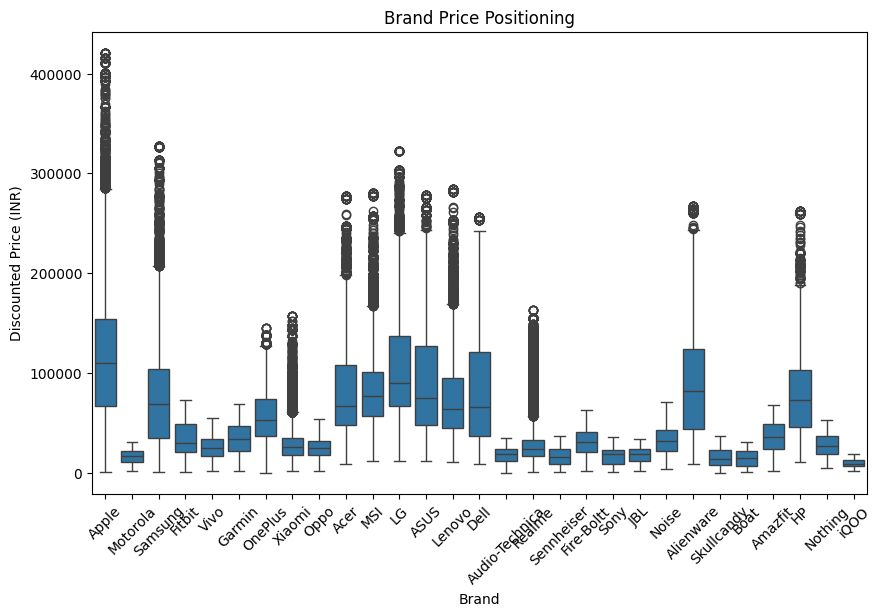

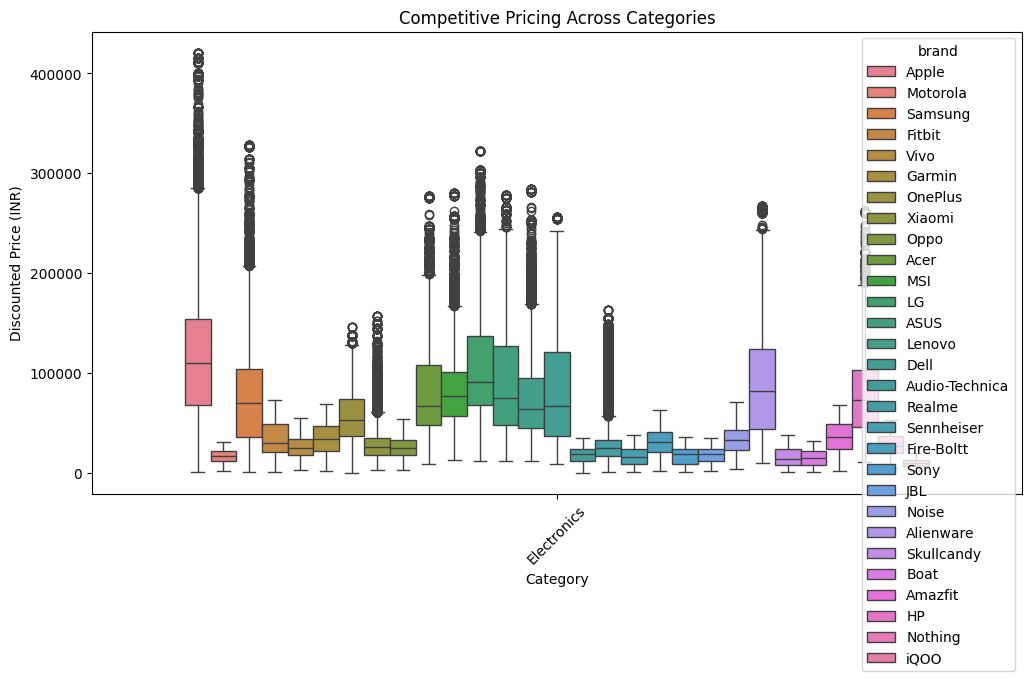

C:\Users\hp\AppData\Local\Temp\ipykernel_11348\2680696996.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['brand', 'price_range'])


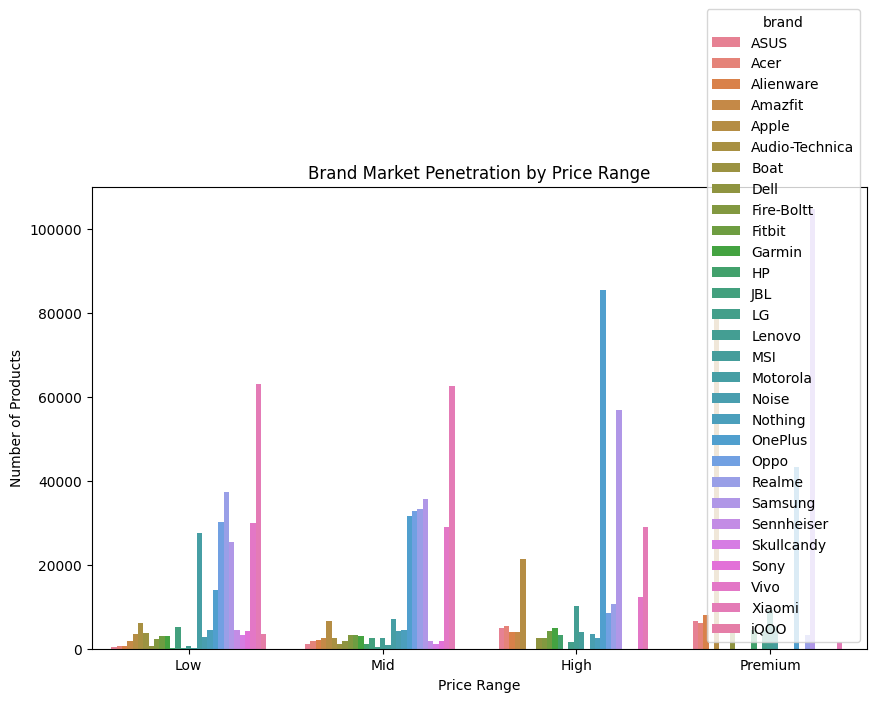

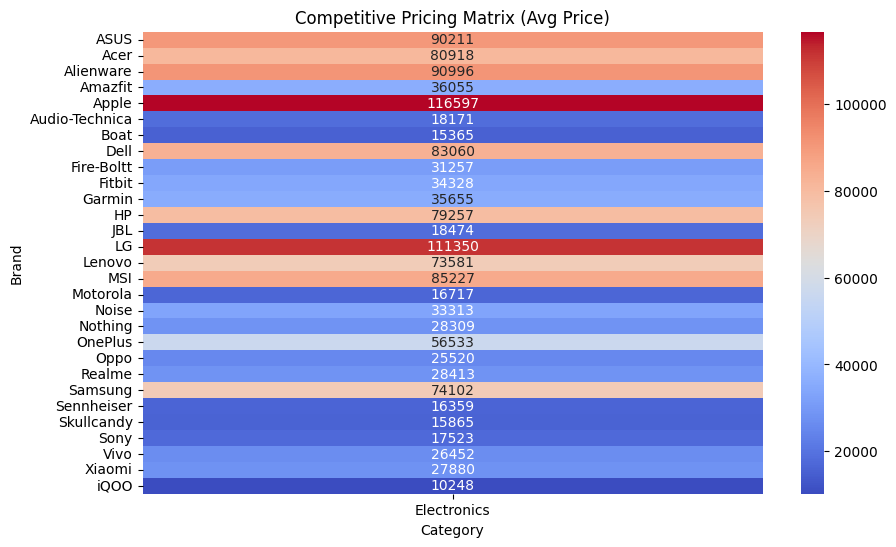

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['discounted_price_inr'] = pd.to_numeric(df['discounted_price_inr'], errors='coerce')

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='brand',
    y='discounted_price_inr'
)
plt.title("Brand Price Positioning")
plt.xlabel("Brand")
plt.ylabel("Discounted Price (INR)")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='category',
    y='discounted_price_inr',
    hue='brand'
)
plt.title("Competitive Pricing Across Categories")
plt.xlabel("Category")
plt.ylabel("Discounted Price (INR)")
plt.xticks(rotation=45)
plt.show()

df['price_range'] = pd.qcut(
    df['discounted_price_inr'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Premium']
)

price_range_dist = (
    df.groupby(['brand', 'price_range'])
      .size()
      .reset_index(name='product_count')
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=price_range_dist,
    x='price_range',
    y='product_count',
    hue='brand'
)
plt.title("Brand Market Penetration by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Products")
plt.show()

competitive_matrix = df.pivot_table(
    values='discounted_price_inr',
    index='brand',
    columns='category',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(competitive_matrix, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("Competitive Pricing Matrix (Avg Price)")
plt.xlabel("Category")
plt.ylabel("Brand")
plt.show()


Question 20
Create a comprehensive business health dashboard combining key metrics like revenue growth, customer acquisition, retention rates, and operational efficiency using multi-panel visualizations with executive summary insights.


C:\Users\hp\AppData\Local\Temp\ipykernel_11348\278938899.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['discounted_price_inr'].sum() / x['customer_id'].nunique())


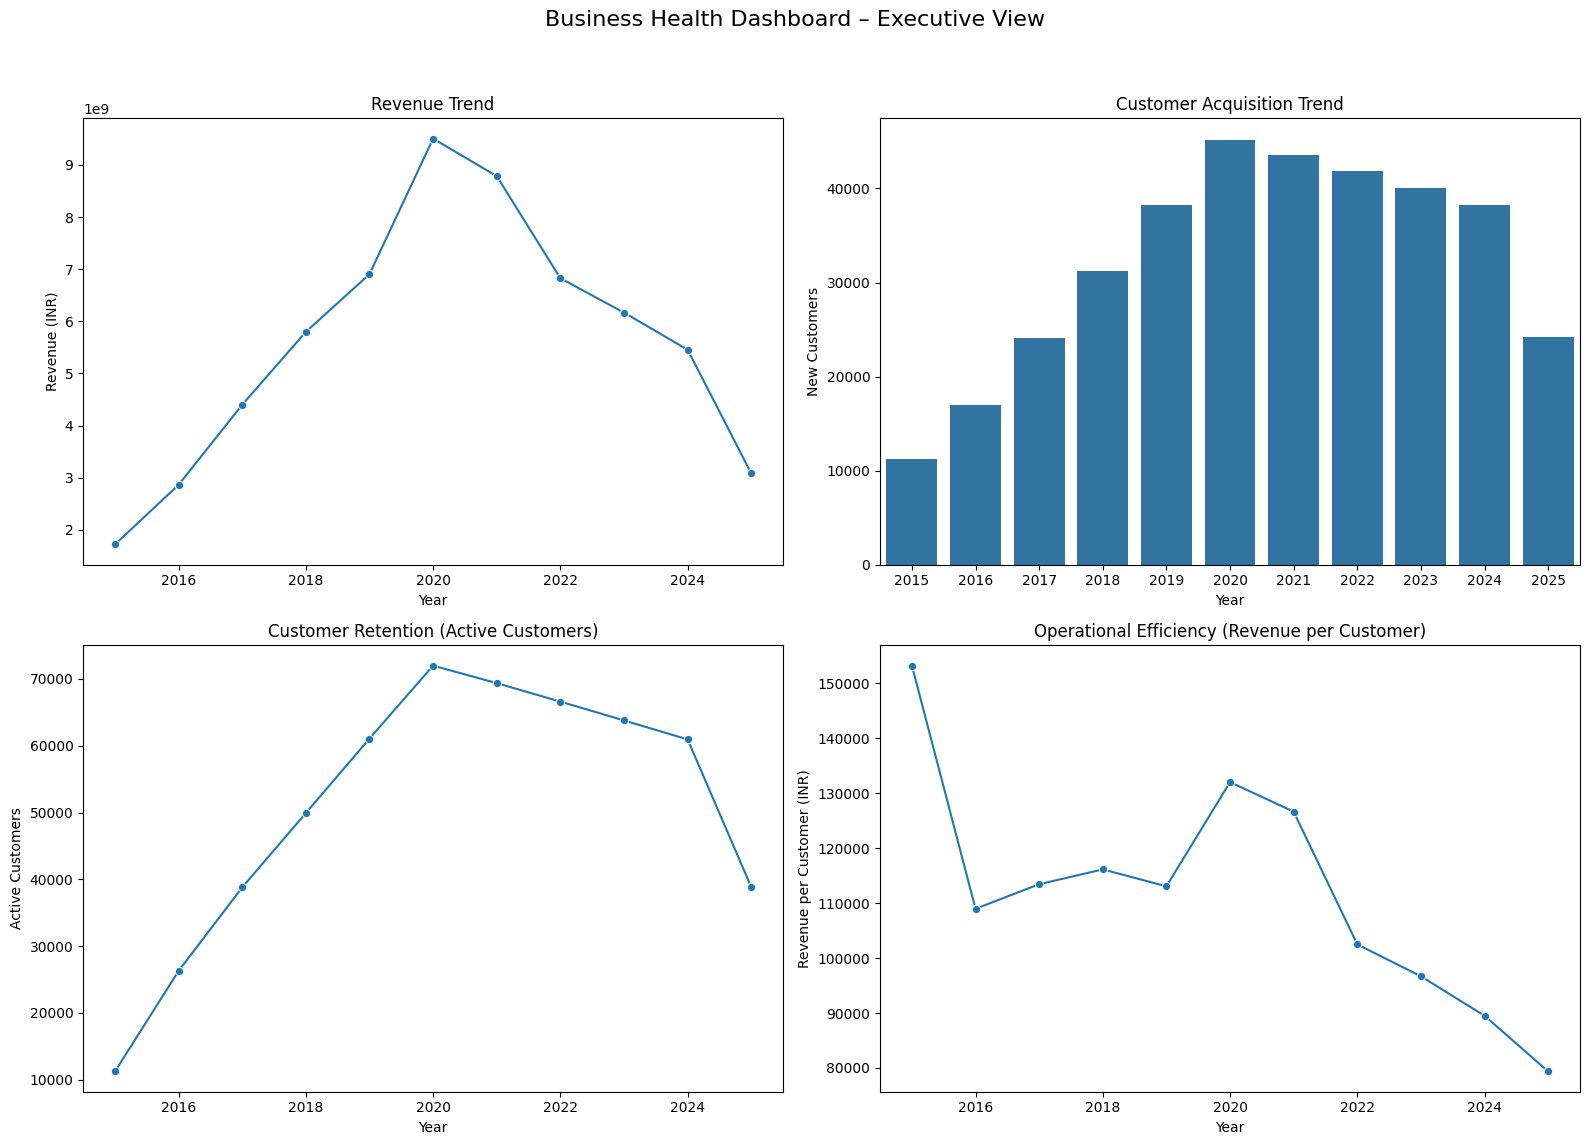

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['order_year'] = df['order_year'].astype(int)

yearly_revenue = (
    df.groupby('order_year')['discounted_price_inr']
      .sum()
      .reset_index()
)

yearly_revenue['revenue_growth_pct'] = (
    yearly_revenue['discounted_price_inr']
    .pct_change() * 100
)

first_purchase = (
    df.groupby('customer_id')['order_year']
      .min()
      .reset_index(name='acquisition_year')
)

customer_acquisition = (
    first_purchase.groupby('acquisition_year')
      .size()
      .reset_index(name='new_customers')
)

customer_year = df[['customer_id', 'order_year']].drop_duplicates()

retention = (
    customer_year.groupby('order_year')['customer_id']
    .nunique()
    .reset_index(name='active_customers')
)

retention['retention_rate_pct'] = (
    retention['active_customers']
    .pct_change() * 100
)

revenue_per_customer = (
    df.groupby('order_year')
      .apply(lambda x: x['discounted_price_inr'].sum() / x['customer_id'].nunique())
      .reset_index(name='revenue_per_customer')
)

plt.figure(figsize=(16,12))


plt.subplot(2,2,1)
sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='discounted_price_inr',
    marker='o'
)
plt.title("Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")


plt.subplot(2,2,2)
sns.barplot(
    data=customer_acquisition,
    x='acquisition_year',
    y='new_customers'
)
plt.title("Customer Acquisition Trend")
plt.xlabel("Year")
plt.ylabel("New Customers")


plt.subplot(2,2,3)
sns.lineplot(
    data=retention,
    x='order_year',
    y='active_customers',
    marker='o'
)
plt.title("Customer Retention (Active Customers)")
plt.xlabel("Year")
plt.ylabel("Active Customers")

plt.subplot(2,2,4)
sns.lineplot(
    data=revenue_per_customer,
    x='order_year',
    y='revenue_per_customer',
    marker='o'
)
plt.title("Operational Efficiency (Revenue per Customer)")
plt.xlabel("Year")
plt.ylabel("Revenue per Customer (INR)")

plt.suptitle("Business Health Dashboard – Executive View", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
